# Stochastic Polynomial Chaos Expansion

This example builds a stochastic polynomial chaos expansion (PCE) surrogate for noisy samples of

$$y(x) = \sin(\pi x) + \varepsilon$$

with

$$\varepsilon \sim \mathcal{N}(0, 0.1^2)$$

We approximate the uncertain model response with a finite chaos basis,

$$\hat{y}(x, \boldsymbol{\xi}) = \sum_{k=0}^{p} c_k \Phi_k(x, \boldsymbol{\xi})$$

and infer an i.i.d. Gaussian distribution over the coefficients using `pypolymix`.

In [45]:
# Import statements
import matplotlib.pyplot as plt
import torch

from pypolymix.parameter_groups import DeterministicGroup, IIDGaussianGroup
from pypolymix.surrogate_models import PolynomialChaosExpansion
from pypolymix import StochasticModel

In [46]:
# Set random seed
_ = torch.manual_seed(1234)

We draw `num_samples = 25` scalar inputs uniformly in $[-1, 1]$ and evaluate $y_i = \sin(\pi x_i) + \varepsilon_i$ with Gaussian noise. This gives us a toy dataset whose curvature the PCE must learn.

In [47]:
# Generate synthetic data
num_samples = 25
X = 2 * torch.rand(num_samples, 1) - 1
Y = torch.sin(torch.pi * X) + 0.1 * torch.randn(X.shape)

A simple scatter plot reveals the wavy trend and the level of observational noise so that we can compare the eventual surrogate predictions against the ground truth samples.

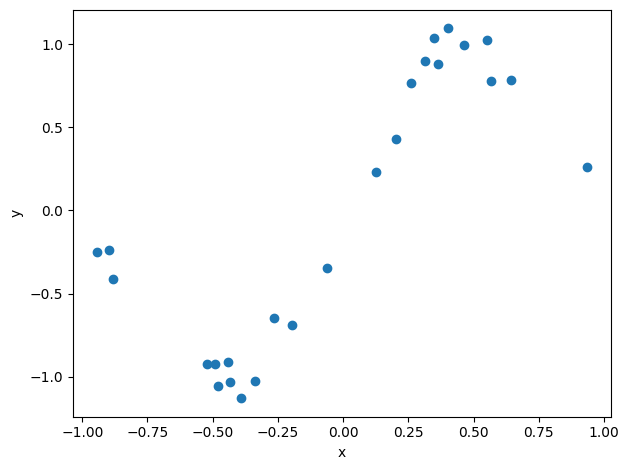

In [48]:
# Plot synthetic data
_, ax = plt.subplots()
ax.scatter(X, Y)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()

`PolynomialChaosExpansion(num_inputs=1, num_outputs=1, degree=5)` creates a one-dimensional chaos basis up to order five. We also print the resulting number of coefficients so we know how many stochastic parameters the training loop will handle.

In [49]:
# Create a surrogate model
surrogate_model = PolynomialChaosExpansion(num_inputs=1, num_outputs=1, degree=5)
num_params = surrogate_model.num_params()
print(f"This model has {num_params} parameters")

This model has 6 parameters


`pypolymix` lets us divide the coefficient vector into interpretable blocks. Here we treat the first two coefficients as i.i.d. Gaussian (a stochastic prior) and the remaining four as deterministic. For the first two coefficients, `pypolymix` will infer a mean and (log of a) standard deviation internally. 

In [50]:
# Create parameter groups
parameter_groups = [
    IIDGaussianGroup("group0", 2),    # Assume first coefficient is iid Gaussian
    DeterministicGroup("group1", 4),  # All other coefficients are deterministic
]

`StochasticModel` couples the surrogate with the declared parameter groups.

In [51]:
# Create stochastic model
model = StochasticModel(
    surrogate_model=surrogate_model, parameter_groups=parameter_groups
)
print(f"Created stochastic model with {model.num_params()} parameters")

Created stochastic model with 6 parameters


We set conventional hyperparameters (`lr`, `weight_decay`, `weight_factor`, `num_epochs`), construct an AdamW optimizer over the model parameters, choose mean-squared error as the data term, and add a `OneCycleLR` schedule to pace the learning rate.

In [52]:
# Training options
lr = 1e-3             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
weight_factor = 5e-1  # Weight factor for distribution loss
num_epochs = 10000    # Number of epochs
num_samples = 100     # Number of parameter samples per epoch

# Optimizer: AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Loss
loss_fn = torch.nn.MSELoss(reduction="sum")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)

During each epoch we draw 100 parameter realizations, push the training inputs through the surrogate, compute the data fit loss on the predictive mean, and add the distribution regularizer weighted by `weight_factor`.

In [53]:
# Train the stochastic model
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Evaluate parameters and model
    params = model.sample_parameters(num_samples=num_samples)
    Y_hat = surrogate_model(X, params)

    # Losses
    data_loss = loss_fn(Y_hat, Y.unsqueeze(0).expand_as(Y_hat)) / num_samples
    distribution_loss = model.distribution_loss()
    total_loss = data_loss + weight_factor * distribution_loss

    # Backprop + step
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if (epoch + 1) % 1000 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch + 1:5d} | "
            f"learning rate = {current_lr:.6f} | "
            f"data loss = {data_loss.item():.4f} | "
            f"distribution loss = {distribution_loss.item():.4f} | "
            f"total loss = {total_loss.item():.4f}"
        )

Epoch  1000 | learning rate = 0.002801 | data loss = 3.9538 | distribution loss = 6.1787 | total loss = 7.0432
Epoch  2000 | learning rate = 0.007603 | data loss = 0.8597 | distribution loss = 7.4630 | total loss = 4.5912
Epoch  3000 | learning rate = 0.010000 | data loss = 0.6857 | distribution loss = 7.7149 | total loss = 4.5432
Epoch  4000 | learning rate = 0.009504 | data loss = 0.7021 | distribution loss = 7.7233 | total loss = 4.5637
Epoch  5000 | learning rate = 0.008116 | data loss = 0.6816 | distribution loss = 7.7523 | total loss = 4.5577
Epoch  6000 | learning rate = 0.006110 | data loss = 0.7567 | distribution loss = 7.7501 | total loss = 4.6318
Epoch  7000 | learning rate = 0.003885 | data loss = 0.6301 | distribution loss = 7.7676 | total loss = 4.5139
Epoch  8000 | learning rate = 0.001881 | data loss = 0.7846 | distribution loss = 7.7322 | total loss = 4.6507
Epoch  9000 | learning rate = 0.000494 | data loss = 0.7777 | distribution loss = 7.7341 | total loss = 4.6447
E

After training we switch to evaluation mode, create a dense set of test inputs, and draw multiple samples from the stochastic model to characterize predictive uncertainty across the domain.

In [54]:
# Evaluate the model
model.eval()
with torch.no_grad():
    X_test = torch.linspace(-1, 1, 101).unsqueeze(1)
    Y_test = model(X_test, num_samples=100)

We summarize the sampled predictions by plotting the posterior mean and the central 90% interval via quantiles, then overlay the original data to visually assess how well the stochastic PCE tracks the signal.

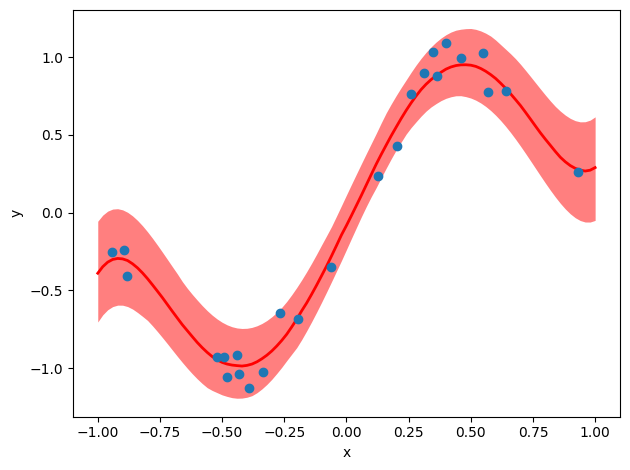

In [55]:
# Plot prediction
_, ax = plt.subplots()
quantiles = torch.quantile(Y_test, torch.tensor([0.05, 0.5, 0.95]), axis=0)
X_plot = X_test.squeeze(-1)
quantiles = quantiles.squeeze(-1)
ax.fill_between(X_plot, quantiles[0], quantiles[-1], color="red", alpha=0.5, linewidth=0)
ax.plot(X_plot, quantiles[1], color="red", linewidth=2)
ax.scatter(X, Y, zorder=99)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()